# Examining differences in distributions 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

In [64]:
target = 'MBOAT7'

In [65]:
#for now manually load dist for one target gene
male_target_contribs = pd.read_csv(f'./data/male_contribution_dists/{target}_reg_cont_distributions.csv', index_col = 0)
female_target_contribs = pd.read_csv(f'./data/female_contribution_dists/{target}_reg_cont_distributions.csv', index_col = 0)

# Effect Size Difference Approach

In [66]:
male_target_contribs = male_target_contribs.fillna(0)
female_target_contribs = female_target_contribs.fillna(0)

In [67]:
male_target_contribs

,ADNP,ADNP2,AEBP1,AEBP2,AHR,AHRR,AIRE,AKNA,ALX4,AR,...,ZSCAN22,ZSCAN23,ZSCAN26,ZSCAN29,ZSCAN31,ZSCAN4,ZSCAN5A,ZSCAN9,ZXDA,ZXDC
0,-0.003126,0.000005,0.022339,-0.000193,0.009005,-0.000124,-0.000083,-0.001430,-0.000028,0.000610,...,0.000013,0.000166,-0.000220,-0.010690,0.000274,0.008390,0.004538,0.000030,-0.000042,0.012300
1,-0.003240,0.000005,0.021931,-0.000186,0.009437,-0.000156,-0.000087,0.000023,-0.000030,0.000463,...,0.000031,0.000174,-0.000242,-0.011036,0.000318,0.008784,0.003539,0.000031,-0.000052,0.011493
2,-0.003463,0.000006,0.023411,-0.000168,0.010078,-0.000166,-0.000093,0.000118,-0.000032,0.000454,...,0.000050,0.000186,-0.000260,-0.011820,0.000349,0.009377,0.003778,0.000034,-0.000047,0.009846
3,-0.003617,0.000006,0.018591,-0.000171,0.010507,-0.000173,-0.000096,0.000016,-0.000033,0.000473,...,0.000052,0.000193,-0.000284,-0.012315,0.000359,0.009769,0.006423,0.000036,-0.000022,0.013177
4,-0.003452,0.000006,0.023298,-0.000152,0.010031,-0.000148,-0.000092,0.000024,-0.000031,0.000454,...,0.000014,0.000185,-0.000255,-0.011745,0.000342,0.009331,0.009327,0.000035,-0.000042,0.011805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,-0.004182,0.000014,0.026326,-0.000134,0.012410,-0.000204,-0.000114,0.000092,-0.000039,0.000597,...,-0.005009,0.000228,-0.000347,-0.014051,0.000460,0.011515,0.004640,0.000029,0.000104,0.007170
709,-0.002683,0.000003,0.019859,-0.000188,0.007633,-0.000126,-0.000070,-0.008173,-0.000024,0.000651,...,0.000106,0.000141,-0.000180,-0.009138,0.000224,0.002558,0.007595,0.000029,-0.000055,0.013400
710,-0.002752,0.000003,0.020309,-0.000203,0.007828,-0.000116,-0.000072,-0.007811,-0.000025,0.000674,...,0.000108,0.000145,-0.000185,-0.009382,0.000227,0.007309,0.008571,0.000027,-0.000047,0.012982
711,-0.002416,0.000003,0.018580,-0.000198,0.006845,-0.000083,-0.000063,-0.009288,-0.000022,0.000572,...,0.000141,0.000127,-0.000163,-0.008233,0.000197,0.002295,0.008908,0.000028,-0.000066,0.012957


In [68]:
#iterate through TFs in male_target_contribs (same as in female)
results_df = pd.DataFrame(index = male_target_contribs.columns, columns = ['abs_mean_cont_diff'])
for TF in male_target_contribs.columns:
    #take the difference between the two columns
    sex_differential = abs(np.mean(male_target_contribs[TF]) - np.mean(female_target_contribs[TF]))
    results_df.loc[TF, 'abs_mean_cont_diff'] = sex_differential

In [69]:
male_target_contribs

,ADNP,ADNP2,AEBP1,AEBP2,AHR,AHRR,AIRE,AKNA,ALX4,AR,...,ZSCAN22,ZSCAN23,ZSCAN26,ZSCAN29,ZSCAN31,ZSCAN4,ZSCAN5A,ZSCAN9,ZXDA,ZXDC
0,-0.003126,0.000005,0.022339,-0.000193,0.009005,-0.000124,-0.000083,-0.001430,-0.000028,0.000610,...,0.000013,0.000166,-0.000220,-0.010690,0.000274,0.008390,0.004538,0.000030,-0.000042,0.012300
1,-0.003240,0.000005,0.021931,-0.000186,0.009437,-0.000156,-0.000087,0.000023,-0.000030,0.000463,...,0.000031,0.000174,-0.000242,-0.011036,0.000318,0.008784,0.003539,0.000031,-0.000052,0.011493
2,-0.003463,0.000006,0.023411,-0.000168,0.010078,-0.000166,-0.000093,0.000118,-0.000032,0.000454,...,0.000050,0.000186,-0.000260,-0.011820,0.000349,0.009377,0.003778,0.000034,-0.000047,0.009846
3,-0.003617,0.000006,0.018591,-0.000171,0.010507,-0.000173,-0.000096,0.000016,-0.000033,0.000473,...,0.000052,0.000193,-0.000284,-0.012315,0.000359,0.009769,0.006423,0.000036,-0.000022,0.013177
4,-0.003452,0.000006,0.023298,-0.000152,0.010031,-0.000148,-0.000092,0.000024,-0.000031,0.000454,...,0.000014,0.000185,-0.000255,-0.011745,0.000342,0.009331,0.009327,0.000035,-0.000042,0.011805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,-0.004182,0.000014,0.026326,-0.000134,0.012410,-0.000204,-0.000114,0.000092,-0.000039,0.000597,...,-0.005009,0.000228,-0.000347,-0.014051,0.000460,0.011515,0.004640,0.000029,0.000104,0.007170
709,-0.002683,0.000003,0.019859,-0.000188,0.007633,-0.000126,-0.000070,-0.008173,-0.000024,0.000651,...,0.000106,0.000141,-0.000180,-0.009138,0.000224,0.002558,0.007595,0.000029,-0.000055,0.013400
710,-0.002752,0.000003,0.020309,-0.000203,0.007828,-0.000116,-0.000072,-0.007811,-0.000025,0.000674,...,0.000108,0.000145,-0.000185,-0.009382,0.000227,0.007309,0.008571,0.000027,-0.000047,0.012982
711,-0.002416,0.000003,0.018580,-0.000198,0.006845,-0.000083,-0.000063,-0.009288,-0.000022,0.000572,...,0.000141,0.000127,-0.000163,-0.008233,0.000197,0.002295,0.008908,0.000028,-0.000066,0.012957


In [70]:
np.mean(female_target_contribs['ZSCAN9'])

np.float64(3.1003899258855587e-05)

In [71]:
np.mean(male_target_contribs['ZSCAN9'])

np.float64(3.082111450070126e-05)

In [72]:
results_df[results_df['abs_mean_cont_diff'] > 0.009]

,abs_mean_cont_diff


In [73]:
actual_female_expressions = pd.read_csv('/home/alexanderb/Zhang_lab/data/Full data files/ARCHS4_female_external_expressions.tsv', sep ='\t', index_col = 0)

In [74]:
actual_male_expressions = pd.read_csv('/home/alexanderb/Zhang_lab/data/Full data files/ARCHS4_male_external_expressions.tsv', sep ='\t', index_col = 0)

In [75]:
actual_female_expressions[target]

GSM3662836    1.447158
GSM3662837    1.505150
GSM3662838    1.380211
GSM3662840    1.491362
GSM3662841    1.447158
                ...   
GSM3664122    1.819544
GSM3664123    1.623249
GSM3664124    1.755875
GSM3664125    1.785330
GSM3664126    1.748188
Name: MBOAT7, Length: 367, dtype: float64

In [76]:
actual_male_expressions[target]

GSM3662850    1.491362
GSM3662852    0.954243
GSM3662853    1.000000
GSM3662854    1.079181
GSM3662855    0.903090
                ...   
GSM3664097    1.342423
GSM3664098    2.230449
GSM3664099    2.245513
GSM3664106    2.346353
GSM3664107    2.301030
Name: MBOAT7, Length: 713, dtype: float64

# Statistical Significance Approach

In [77]:
from scipy.stats import mannwhitneyu

In [78]:
TFs = [None] * len(male_target_contribs.columns)
PVals = [None] * len(male_target_contribs.columns)
for i in range(0, len(male_target_contribs.columns)):
    TFs[i] = male_target_contribs.columns[i]
    #t_statistic, p_value = stats.ttest_ind(male_target_contribs[TFs[i]], female_target_contribs[TFs[i]])
    print(stats.anderson(male_target_contribs[TFs[i]], method = 'interpolate'))
    print(stats.anderson(female_target_contribs[TFs[i]], method = 'interpolate'))
    t_statistic, p_value = mannwhitneyu(male_target_contribs[TFs[i]], female_target_contribs[TFs[i]])
    PVals[i] = p_value
    #dist_diff_dictionary[TF] = {'t_stat' : t_statistic, 'p_val':p_value}

SignificanceResult(statistic=np.float64(27.163547436687395), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(14.845904023612775), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(125.95933267252894), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(18.212087211040057), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(22.957236357240276), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(14.079119319080746), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(224.98169864566535), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(10.027814623429094), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(28.49043371405355), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(15.180084313329473), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(10.526567665871426), pvalue=np.float64(0.01))
SignificanceResult(statistic=np.float64(7.1139523133946

In [79]:
min(PVals)

np.float64(2.088318929525551e-12)

In [80]:
max(PVals)

np.float64(0.9968775712799703)

In [81]:
#control for multiple testing with BJH correction
adjusted_PVals = stats.false_discovery_control(PVals, method = 'bh')

In [82]:
results_df = pd.DataFrame(columns = ['Gene', 'pval', 'adj_pval'])
results_df['Gene'] = TFs
results_df['pval'] = PVals
results_df['adj_pval'] = adjusted_PVals

In [83]:
#results_df[results_df['adj_pval'] < 0.01].Gene.to_csv(f'./data/diff_contributing_genes/{target}_differential_regulators.csv')

In [84]:

with open(f'./data/diff_contributing_genes/{target}_differential_regulators.txt', 'w+') as f:
    for gene in results_df[results_df['adj_pval'] < 0.05].Gene:
        f.write(f'{gene}\n')
f.close

<function TextIOWrapper.close()>

# visualising final file

In [2]:
threshold = 1
file_path = f'/home/alexanderb/Zhang_lab/MML_model/GRN_reconstruction/data/GW_diff_regulatorts_{threshold}.csv'
results = pd.read_csv(file_path, index_col = 0)

In [17]:
len(set(results['TF']))

1062

In [5]:
results

,TF,TG,abs_diff,Male_mean_exp,Female_mean_exp,Exp_difference
0,AEBP2,A2ML1,0.107908,0.051510,0.033228,0.018282
1,AHRR,A2ML1,0.033215,0.051510,0.033228,0.018282
2,ARGFX,A2ML1,0.071206,0.051510,0.033228,0.018282
3,ARID3A,A2ML1,0.192383,0.051510,0.033228,0.018282
4,ARID3B,A2ML1,0.140783,0.051510,0.033228,0.018282
...,...,...,...,...,...,...
38999587,ZSCAN1,ZKSCAN1,2.177954,2.386444,2.303049,0.083394
38999588,ZSCAN23,ZKSCAN1,2.257392,2.386444,2.303049,0.083394
38999589,ZSCAN26,ZKSCAN1,1.937395,2.386444,2.303049,0.083394
38999590,ZSCAN31,ZKSCAN1,1.153093,2.386444,2.303049,0.083394


<Axes: xlabel='Exp_difference', ylabel='abs_diff'>

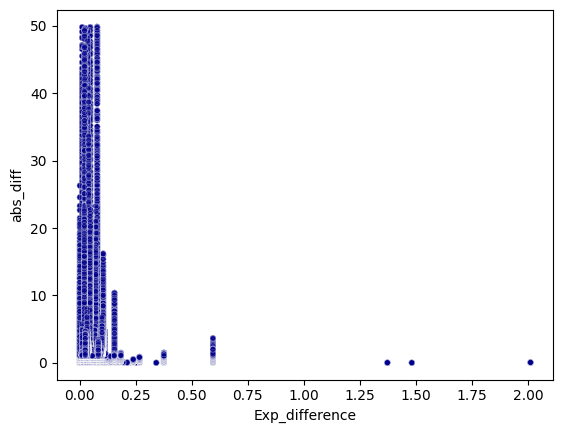

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(results, x = 'Exp_difference', y = 'abs_diff', size = 3, color = 'darkblue', alpha = 0.5, legend = False)

In [4]:
results = results[results['abs_diff'] <= 50]
results.to_csv(file_path)

In [ ]:
#results_check = results[results['Exp_difference'] > 0.1]
#results_check

,TF,TG,abs_diff,Male_mean_exp,Female_mean_exp,Exp_difference
6655,ADNP,ALPK2,0.505625,0.832267,1.098985,0.266718
6656,AEBP1,ALPK2,0.251201,0.832267,1.098985,0.266718
6657,AEBP2,ALPK2,0.207582,0.832267,1.098985,0.266718
6658,ALX4,ALPK2,0.208729,0.832267,1.098985,0.266718
6659,AR,ALPK2,0.611439,0.832267,1.098985,0.266718
...,...,...,...,...,...,...
2088223,ZXDA,TIMP1,0.446863,2.720589,2.609142,0.111447
2407171,FOSB,TRPM8,0.215095,2.160092,2.059324,0.100768
2407172,LHX2,TRPM8,0.220352,2.160092,2.059324,0.100768
2754685,FOSL2,YBX3,0.203058,1.829262,1.659049,0.170213


In [25]:
'FOSL2' in list(results['TF'])

True

In [134]:
diff_regulated = set(results['TG'])
diff_regulators = set(results['TF'])

In [135]:
len(diff_regulators)

1062

In [136]:
len(diff_regulated)

275

In [137]:
with open(f'./data/{threshold}_differential_regulated.txt', 'w+') as f:
    for gene in diff_regulated:
        f.write(f'{gene}\n')
f.close

<function TextIOWrapper.close()>

In [138]:
with open(f'./data/{threshold}_differential_regulators.txt', 'w+') as f:
    for gene in diff_regulators:
        f.write(f'{gene}\n')
f.close

<function TextIOWrapper.close()>

In [15]:
results[results['TF'] == target]

,TF,TG,abs_diff,Male_mean_exp,Female_mean_exp,Exp_difference


In [16]:
target = 'CYP4'
results[results['TG'] == target].to_csv(f'{file_path}_{target}.csv')